# Полиномиальные модели

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv")
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


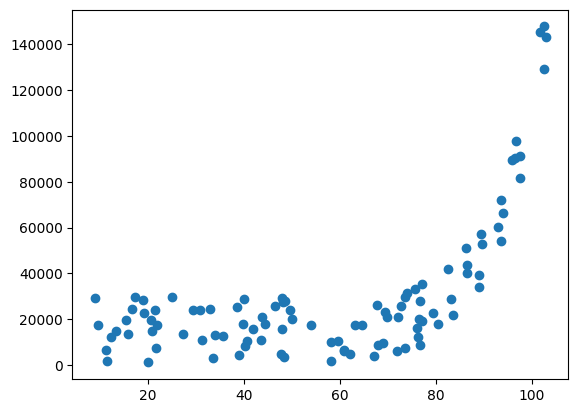

In [15]:
X = pd.DataFrame(data.x)
y = data.y
plt.scatter(X, y)

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


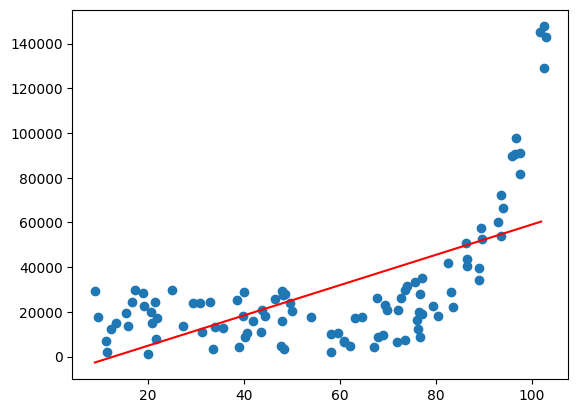

In [16]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression().fit(X, y)

X = pd.DataFrame(X)

xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

In [17]:
linear.score(X, y)

0.37467360318911636

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


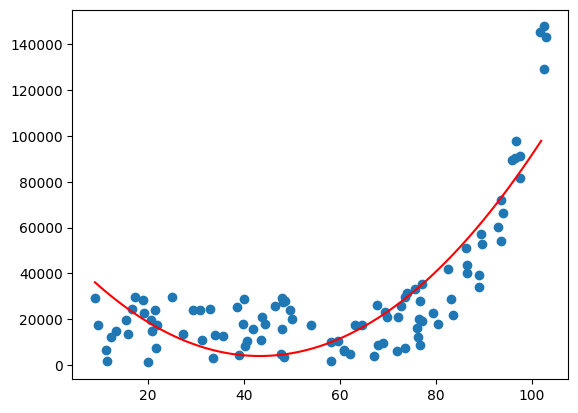

In [18]:
from sklearn.preprocessing import PolynomialFeatures

transformation = PolynomialFeatures(degree=2)
transformation.fit(X)
X_2 = transformation.transform(X)
X_2.shape
X_2[:5]
poly_2d = LinearRegression().fit(X_2, y)
xx_2d = transformation.transform(pd.DataFrame(xx))
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

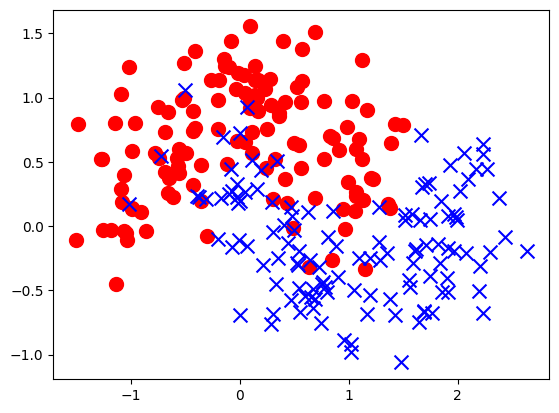

In [19]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv", index_col=0)

y = data.y
X = data.drop(["y"], axis=1)

plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


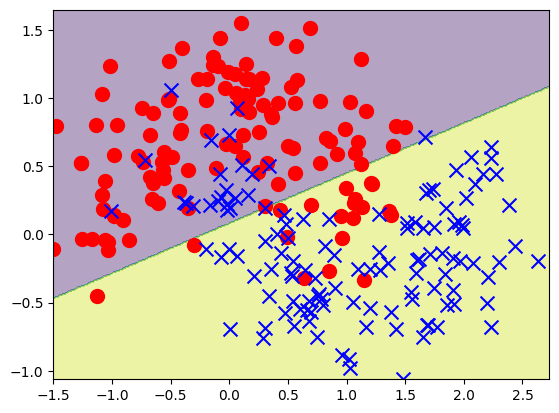

In [20]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression().fit(X, y)
xx, yy = np.meshgrid(
    np.arange(X.iloc[:, 0].min(), X.iloc[:, 0].max()+0.1, 0.01),
    np.arange(X.iloc[:, 1].min(), X.iloc[:, 1].max()+0.1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [21]:
logistic.score(X, y)

0.832

In [22]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)

X_3.shape

(250, 9)

c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


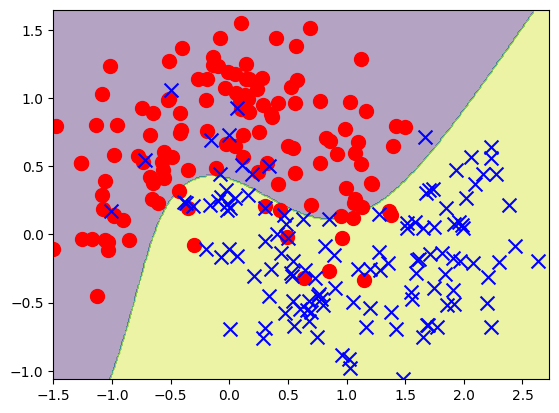

In [23]:
class_3 = LogisticRegression().fit(X_3, y)

Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

In [24]:
class_3.score(X_3, y)

0.9

In [25]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

In [26]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [27]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

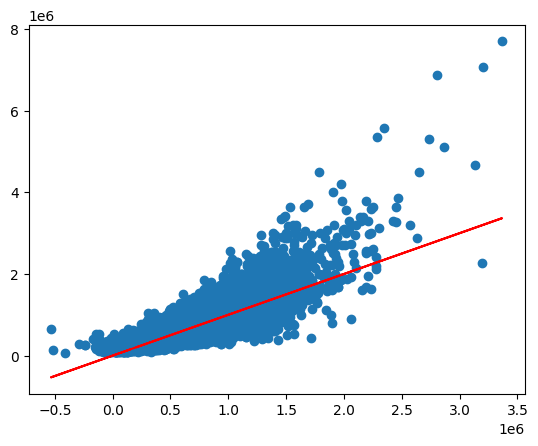

In [28]:
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

In [29]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)
X_3_kc_prices.shape

(21613, 1330)

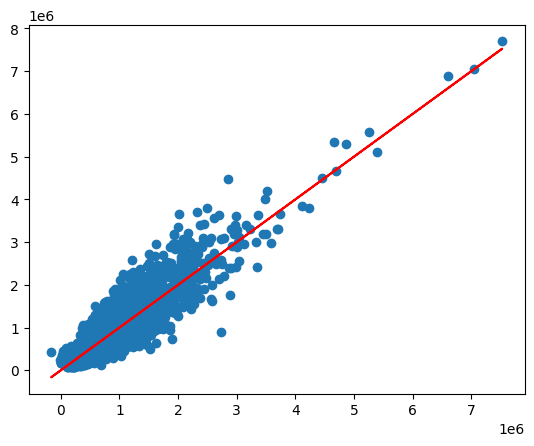

In [30]:
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

# Задания для самостоятельного выполнения

#### 1. В выполненной работе добавьте замер времени обучения каждой модели.

In [31]:
import time

start = time.time()
model = LinearRegression().fit(X, y)
end = time.time()
train_time = end - start
print("training time:", train_time)

training time: 0.00904536247253418


In [32]:
start = time.time()
poly_features_kc_prices = PolynomialFeatures(degree=2)
X_2_kc_prices = poly_features_kc_prices.fit_transform(X_kc_prices)
reg_poly2_kc = LinearRegression().fit(X_2_kc_prices, y_kc_prices)
end = time.time()

print("polynomial model score:", reg_poly2_kc.score(X_2_kc_prices, y_kc_prices))
print("training time:", end - start)

polynomial model score: 0.8084496108134553
training time: 0.5057563781738281


In [33]:
start = time.time()
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
end = time.time()

print("linear model (King County) score:", reg_kc_multiple.score(X_kc_prices, y_kc_prices))
print("training time:", end - start)

linear model (King County) score: 0.699747189010915
training time: 0.037522077560424805


#### 2. На датасете "gen_regression" постройте модель пятого, десятого и сотого порядков. Сравните эффективность и время обучения каждой модели.

In [34]:
degrees = [5, 10, 100]
results_regression = []

for d in degrees:
    start = time.time()
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    end = time.time()
    score = model.score(X_poly, y)

    results_regression.append({
        "degree": d,
        "score": score,
        "time": end - start
    })

for r in results_regression:
    print(r)

{'degree': 5, 'score': 0.6755976386755242, 'time': 0.011022806167602539}
{'degree': 10, 'score': 0.7439555827260853, 'time': 0.015962839126586914}
{'degree': 100, 'score': 0.04708994395015964, 'time': 0.3332180976867676}


#### 3. То же самое проделайте с датасетом для классификации и "King county".

In [35]:
# classification dataset
degrees = [5, 10, 100]
results_class = []

for d in degrees:
    start = time.time()
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LogisticRegression(max_iter=5000).fit(X_poly, y)
    end = time.time()
    score = model.score(X_poly, y)

    results_class.append({
        "degree": d,
        "score": score,
        "time": end - start
    })

for r in results_class:
    print(r)

{'degree': 5, 'score': 0.916, 'time': 0.023275136947631836}
{'degree': 10, 'score': 0.924, 'time': 0.04167652130126953}
{'degree': 100, 'score': 0.5, 'time': 0.15731215476989746}


c:\Users\vadve\VS_Projects\misis_ml_course_6sem\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
# King County dataset
degrees = [1, 2, 3] # 5 10 100 - слишком долго обучается из за объема датасета
results_kc = []

for d in degrees:
    start = time.time()
    poly = PolynomialFeatures(degree=d, include_bias=False, interaction_only=True)
    X_poly = poly.fit_transform(X_kc_prices)
    model = LinearRegression().fit(X_poly, y_kc_prices)
    end = time.time()
    score = model.score(X_poly, y_kc_prices)

    results_kc.append({
        "degree": d,
        "score": score,
        "time": end - start
    })

for r in results_kc:
    print(r)

{'degree': 1, 'score': 0.6997471890109155, 'time': 0.050406694412231445}
{'degree': 2, 'score': 0.8096003799680389, 'time': 0.41826486587524414}
{'degree': 3, 'score': 0.8308401390592415, 'time': 4.382327556610107}


#### 4. Составьте таблицу эффективности разных моделей для каждой задачи. В таблице должна быть информация о времени обучения модели и получившейся точности. Сделайте вывод о целесообразности применения разных степеней полиномов.

In [37]:
import pandas as pd

# table = pd.DataFrame(results_regression)
# print(table)

print("Regression dataset")
print(pd.DataFrame(results_regression))

print("\nClassification dataset")
print(pd.DataFrame(results_class))

print("\nKing County dataset")
print(pd.DataFrame(results_kc))

Regression dataset
   degree     score      time
0       5  0.675598  0.011023
1      10  0.743956  0.015963
2     100  0.047090  0.333218

Classification dataset
   degree  score      time
0       5  0.916  0.023275
1      10  0.924  0.041677
2     100  0.500  0.157312

King County dataset
   degree     score      time
0       1  0.699747  0.050407
1       2  0.809600  0.418265
2       3  0.830840  4.382328


#### 5. Для линейной модели в задаче о продаже домов выведите коэффициенты модели и названия соответствующих атрибутов. Сделайте вывод об относительной важности атрибутов.

In [38]:
coefficients = pd.DataFrame({
    "Feature": X_kc_prices.columns,
    "Coefficient": reg_kc_multiple.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

          Feature    Coefficient
14            lat  602748.226449
5      waterfront  582960.458423
8           grade   95890.445151
6            view   52870.942384
1       bathrooms   41144.278532
7       condition   26385.649139
4          floors    6689.550115
2     sqft_living     110.442865
9      sqft_above      70.785224
10  sqft_basement      39.657640
16  sqft_living15      21.681400
12   yr_renovated      19.812584
3        sqft_lot       0.128598
17     sqft_lot15      -0.382642
13        zipcode    -582.419866
11       yr_built   -2620.223211
0        bedrooms  -35766.541444
15           long -214729.828253


#### 6. Попробуйте также проинтерпретировать полиномиальную модель.

In [39]:
feature_names = poly_features_kc_prices.get_feature_names_out(X_kc_prices.columns)

coefficients_poly = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": reg_poly2_kc.coef_
})

print(coefficients_poly.head(20))

          Feature   Coefficient
0               1     -0.003850
1        bedrooms     -9.862599
2       bathrooms      3.804003
3     sqft_living  -2037.099195
4        sqft_lot   -147.670582
5          floors      6.753587
6      waterfront      0.710025
7            view      6.837642
8       condition     -9.678186
9           grade      8.880915
10     sqft_above  14208.787854
11  sqft_basement -16245.893513
12       yr_built   -248.759161
13   yr_renovated  31787.770930
14        zipcode    -79.287568
15            lat     -0.014443
16           long      0.377134
17  sqft_living15  14786.378790
18     sqft_lot15   1136.898521
19     bedrooms^2    578.341870
